<a href="https://colab.research.google.com/github/sukritimahajan35/Credit-Card-Fraud-Detection-Using-Machine-Learning/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For Google Colab integration
from google.colab import drive

# For preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from scipy.stats import yeojohnson

# For handling class imbalance (undersampling option)
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# For modeling
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

# Reset seaborn defaults
sns.reset_defaults()

Mount Google Drive & Load Data

In [ ]:
drive.mount('/content/drive')
FILE_PATH = '/content/drive/MyDrive/credit_card_fraud_2025.csv'

# Load dataset
df = pd.read_csv(FILE_PATH)
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("First 10 rows:")
display(df.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: (500000, 16)
First 10 rows:


,Transaction_ID,Customer_ID,Transaction_Date,Amount,Merchant_Category,Merchant_ID,Card_Type,Transaction_Type,Country,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Device_Type,Fraud_Flag
0,1,25795,28-05-2025 11:54,81.53,Online Services,8459,Gold,POS,Germany,1,1,0,1.61,11,Web,0
1,2,10860,11-09-2024 20:26,52.19,Fuel,8205,Debit,ATM,Germany,0,1,0,15.77,20,Web,0
2,3,86820,02-11-2024 12:39,27.70,Utilities,8076,Gold,Online,USA,0,1,0,9.19,12,Terminal,0
3,4,64886,08-10-2024 21:58,9.80,Clothing,3244,Gold,ATM,USA,0,1,0,9.42,21,Web,0
4,5,16265,25-05-2024 20:01,178.06,Electronics,3675,Gold,ATM,Germany,0,1,1,1.32,20,Web,0
5,6,92386,17-04-2024 18:31,395.10,Clothing,5194,Credit,Online,Australia,1,0,1,6.05,18,Terminal,0
6,7,47194,09-08-2024 17:10,67.33,Travel,7554,Gold,ATM,India,0,0,1,2.92,17,Web,0
7,8,97498,02-08-2025 15:02,100.11,Travel,6787,Credit,POS,USA,0,0,0,4.92,15,Mobile,0
8,9,54131,07-07-2024 08:34,42.59,Electronics,7780,Gold,ATM,Canada,0,0,0,3.06,8,Mobile,0
9,10,70263,04-09-2024 22:55,111.45,Online Services,5840,Debit,POS,Germany,0,0,1,4.22,22,Web,0


Initial Data Inspection

In [ ]:
print("Data Types:")
print(df.dtypes)

Data Types:
Transaction_ID          int64
Customer_ID             int64
Transaction_Date       object
Amount                float64
Merchant_Category      object
Merchant_ID             int64
Card_Type              object
Transaction_Type       object
Country                object
Is_International        int64
Is_Chip                 int64
Is_Pin_Used             int64
Distance_From_Home    float64
Hour_of_Day             int64
Device_Type            object
Fraud_Flag              int64
dtype: object


In [ ]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      500000 non-null  int64  
 1   Customer_ID         500000 non-null  int64  
 2   Transaction_Date    500000 non-null  object 
 3   Amount              500000 non-null  float64
 4   Merchant_Category   500000 non-null  object 
 5   Merchant_ID         500000 non-null  int64  
 6   Card_Type           500000 non-null  object 
 7   Transaction_Type    500000 non-null  object 
 8   Country             500000 non-null  object 
 9   Is_International    500000 non-null  int64  
 10  Is_Chip             500000 non-null  int64  
 11  Is_Pin_Used         500000 non-null  int64  
 12  Distance_From_Home  500000 non-null  float64
 13  Hour_of_Day         500000 non-null  int64  
 14  Device_Type         500000 non-null  object 
 15  Fraud_Flag          

Handle Missing Values

In [ ]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values detected, imputing numeric columns using KNN.")
    df = df.replace(['', 'NaN', 'NULL', 'null', 'None', -999], np.nan)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    imputer = KNNImputer(n_neighbors=5)
    df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

No missing values found.


Basic Statistical Summary

In [ ]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Transaction_ID,Customer_ID,Amount,Merchant_ID,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Fraud_Flag
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000
mean,250000.500000,55007.627196,145.268014,5501.226076,0.149132,0.300222,0.19980,5.001699,11.513692,0.015000
std,144337.711634,25995.094710,120.882326,2597.483856,0.356219,0.458355,0.39985,4.998739,6.915274,0.121553
min,1.000000,10000.000000,1.190000,1000.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,125000.750000,32490.000000,60.790000,3254.000000,0.000000,0.000000,0.00000,1.430000,6.000000,0.000000
50%,250000.500000,55056.500000,109.160000,5500.000000,0.000000,0.000000,0.00000,3.480000,12.000000,0.000000
75%,375000.250000,77510.000000,192.232500,7751.000000,0.000000,1.000000,0.00000,6.920000,18.000000,0.000000
max,500000.000000,99998.000000,1731.550000,9998.000000,1.000000,1.000000,1.00000,68.130000,23.000000,1.000000


Remove Duplicates

In [ ]:
duplicates = df.duplicated().sum()
print(f"Duplicates Found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")

Duplicates Found: 0


Identify Feature & Target Columns

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

target_col = 'Fraud_Flag'
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

if target_col in numeric_cols:
    numeric_cols.remove(target_col)
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Target: {target_col}")

Numeric features: 9
Categorical features: 6
Target: Fraud_Flag


Outlier Removal (IQR Method)

In [ ]:
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean.reset_index(drop=True)

df = remove_outliers_iqr(df, numeric_cols)
print(f"Dataset shape after outlier removal: {df.shape}")

Dataset shape after outlier removal: (308357, 16)


Handle Skewness (Yeo-Johnson)

In [ ]:
skewed_cols = [col for col in numeric_cols if abs(df[col].skew()) > 1]
if skewed_cols:
    for col in skewed_cols:
        df[col], _ = yeojohnson(df[col])
    print(f"Applied Yeo-Johnson transformation on: {skewed_cols}")

Applied Yeo-Johnson transformation on: ['Distance_From_Home']


Encode Categorical Variables

In [ ]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

Exploratory Data Analysis (EDA)

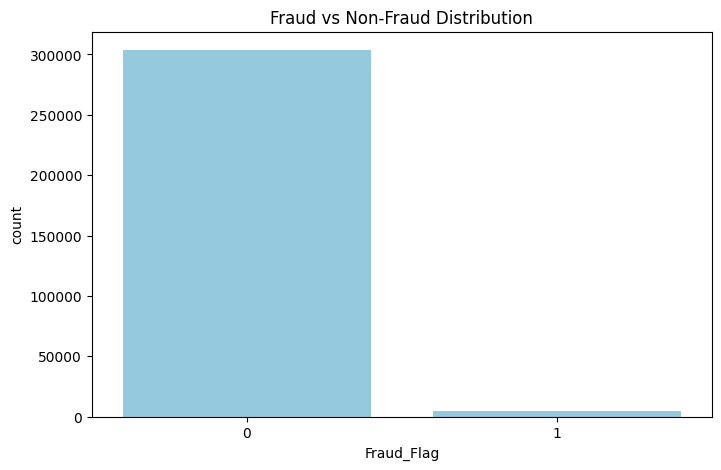

In [ ]:
# Target Distribution
plt.figure(figsize=(8,5))
sns.countplot(x=target_col, data=df, color='skyblue')
plt.title('Fraud vs Non-Fraud Distribution')
plt.show()

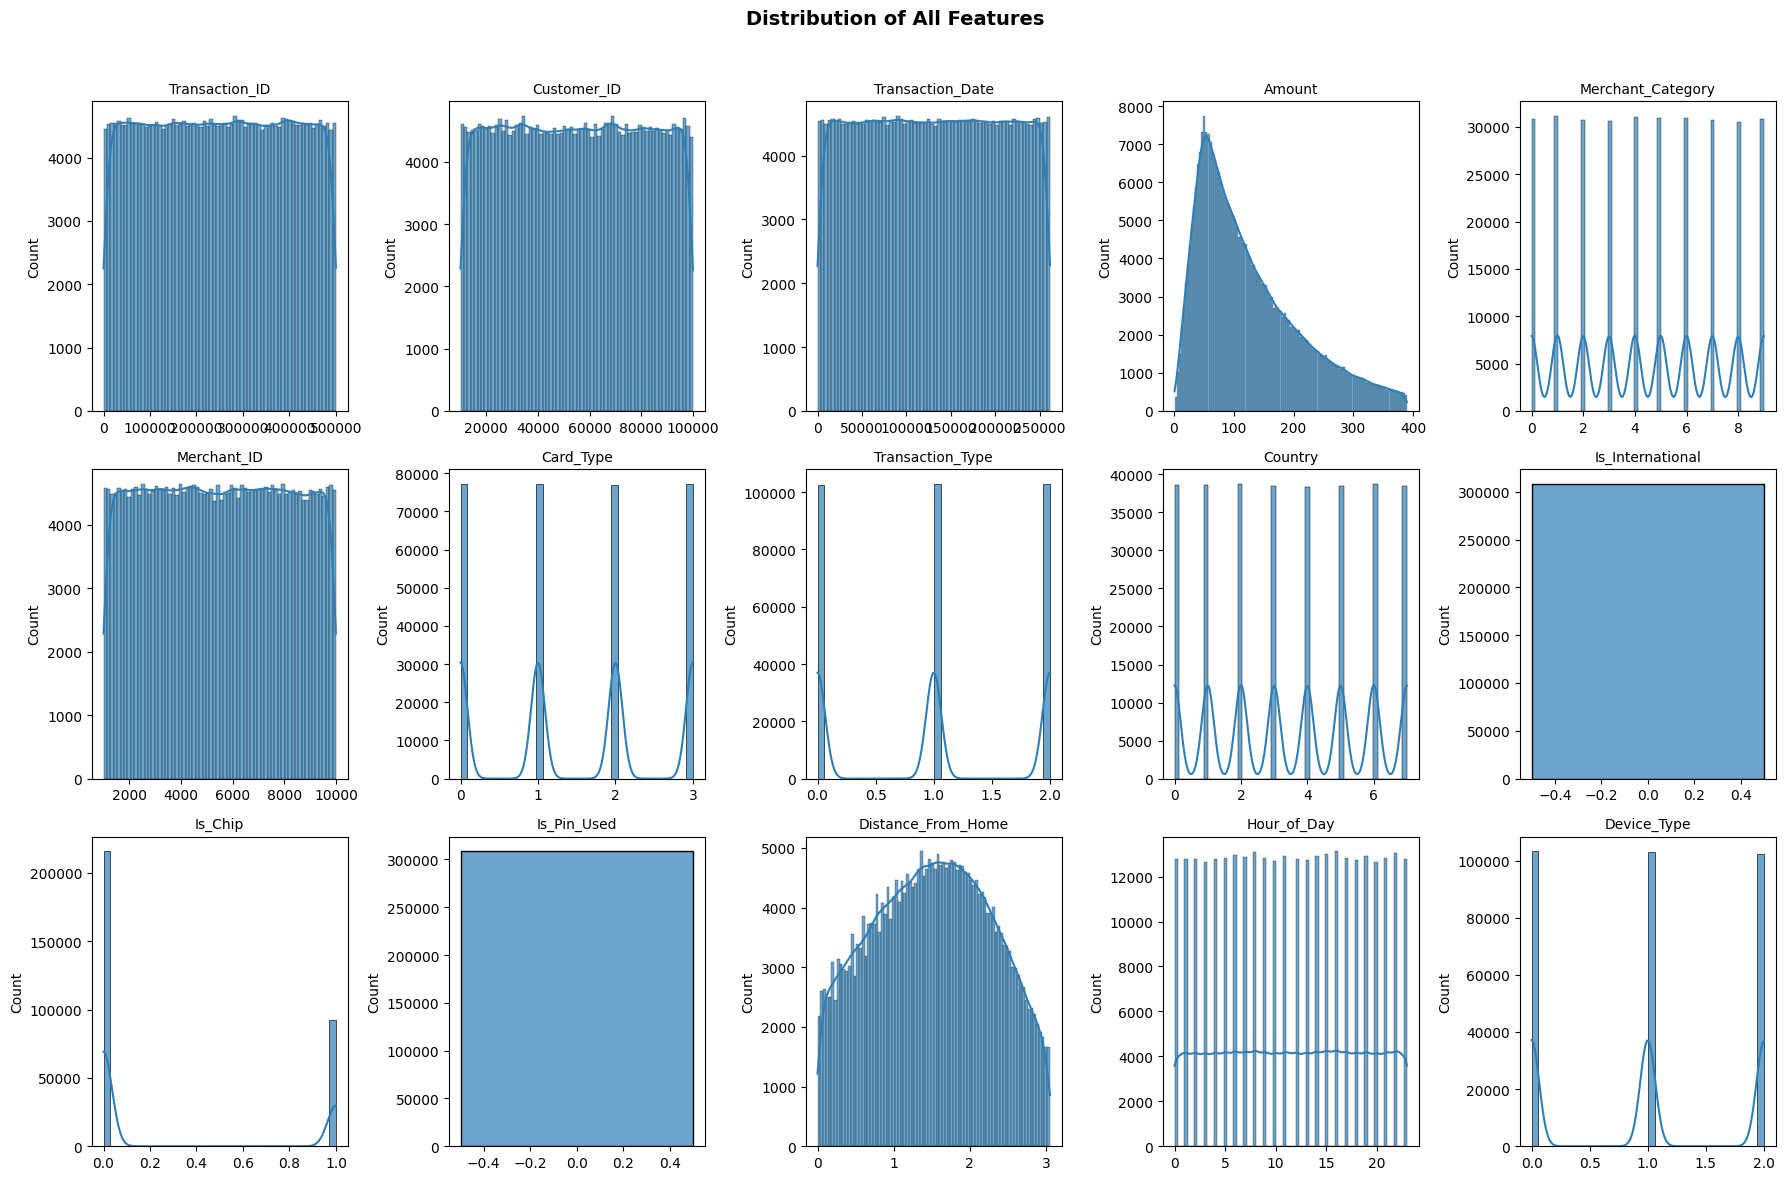

In [ ]:
# Feature Distributions
feature_columns = [col for col in df.columns if col != target_col]
n_features = len(feature_columns)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#2C7FB8', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distribution of All Features", fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

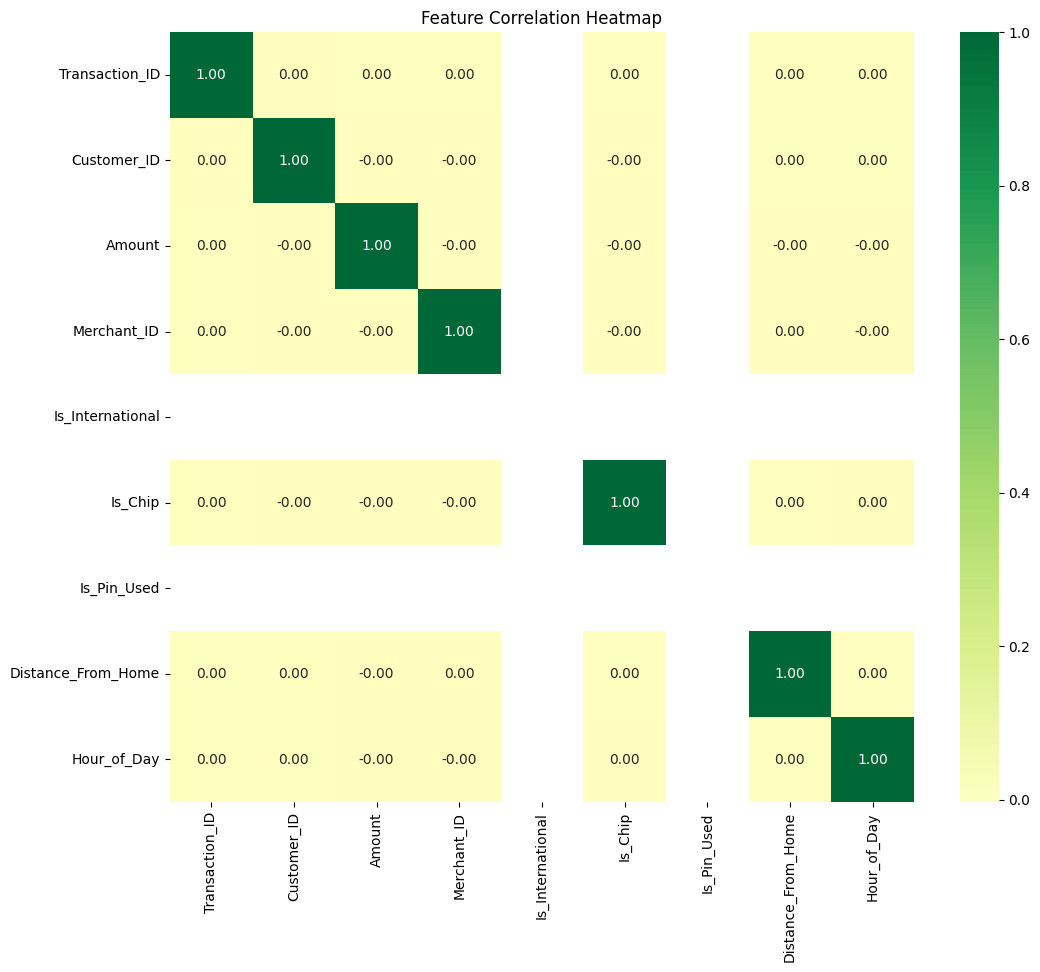

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdYlGn', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

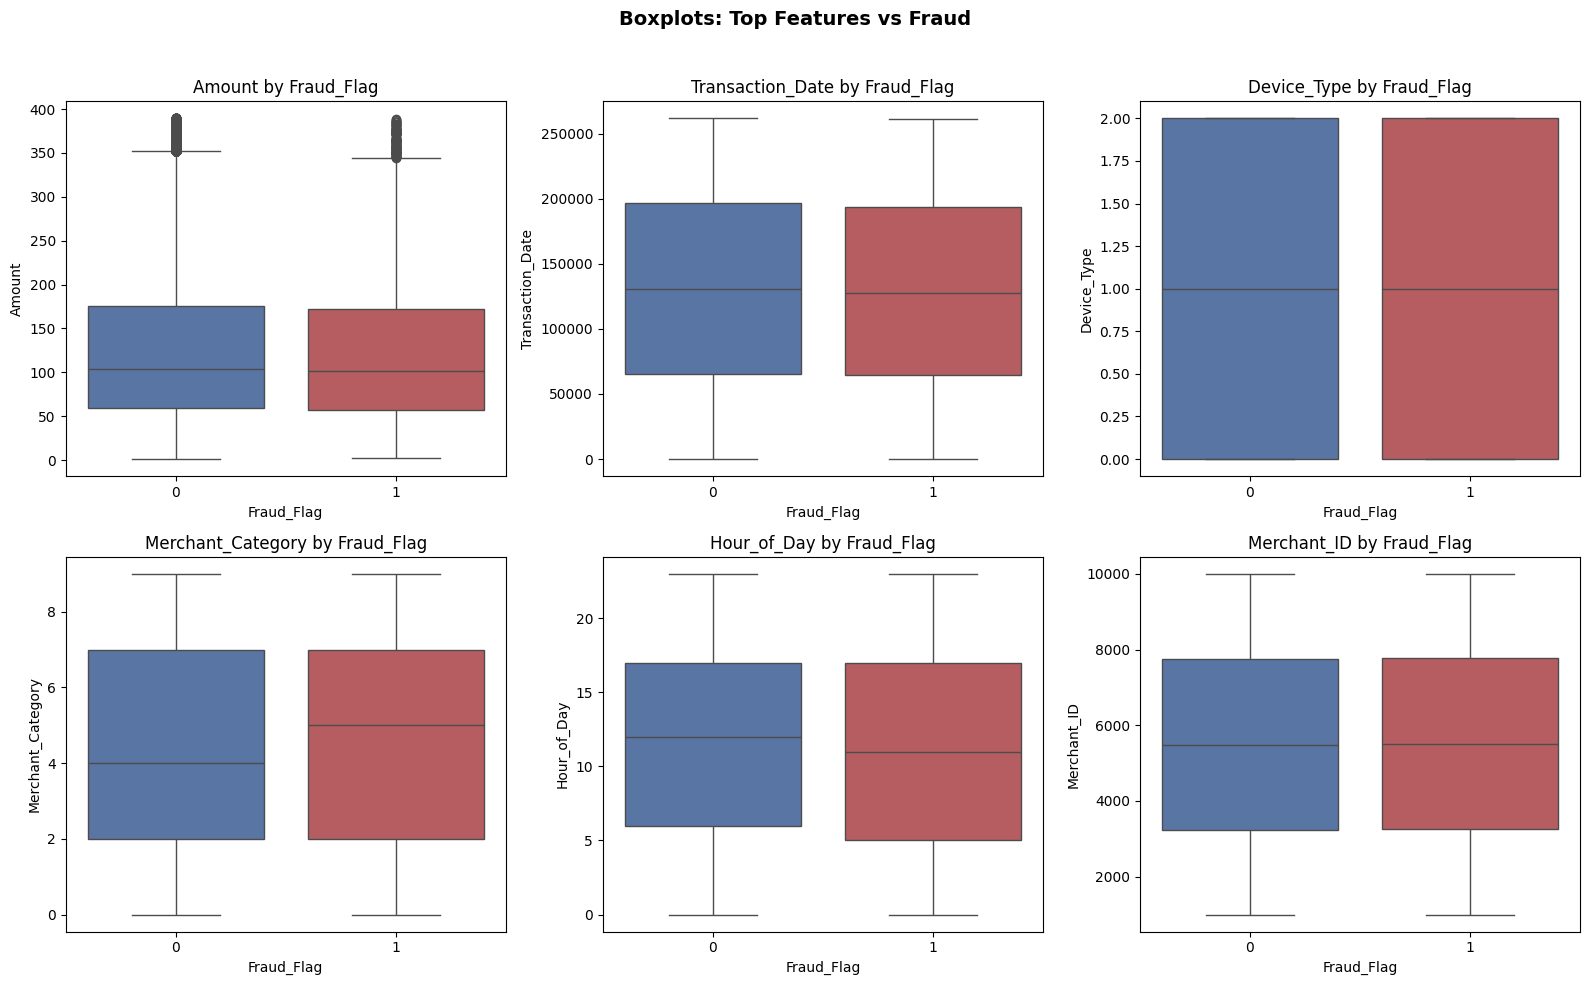

In [ ]:
# Boxplots of Top Correlated Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Compute correlation with target
corr_with_target = df[numeric_cols + [target_col]].corr()[target_col].abs().sort_values(ascending=False)
top_features = corr_with_target.index[1:7]  # Top 6 features

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(
        data=df,
        x=target_col,
        y=col,
        ax=axes[i],
        hue=target_col,
        palette=['#4C72B0', '#C44E52'],
        dodge=False                   # Makes one box per class
    )
    axes[i].set_title(f'{col} by {target_col}', fontsize=12)
    axes[i].legend_.remove()           # Remove duplicate legend

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots: Top Features vs Fraud', fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/tmp/ipython-input-593679612.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(target_col, group_keys=False).apply(


Sampled 5000 rows for pairplot.


<Figure size 1200x1000 with 0 Axes>

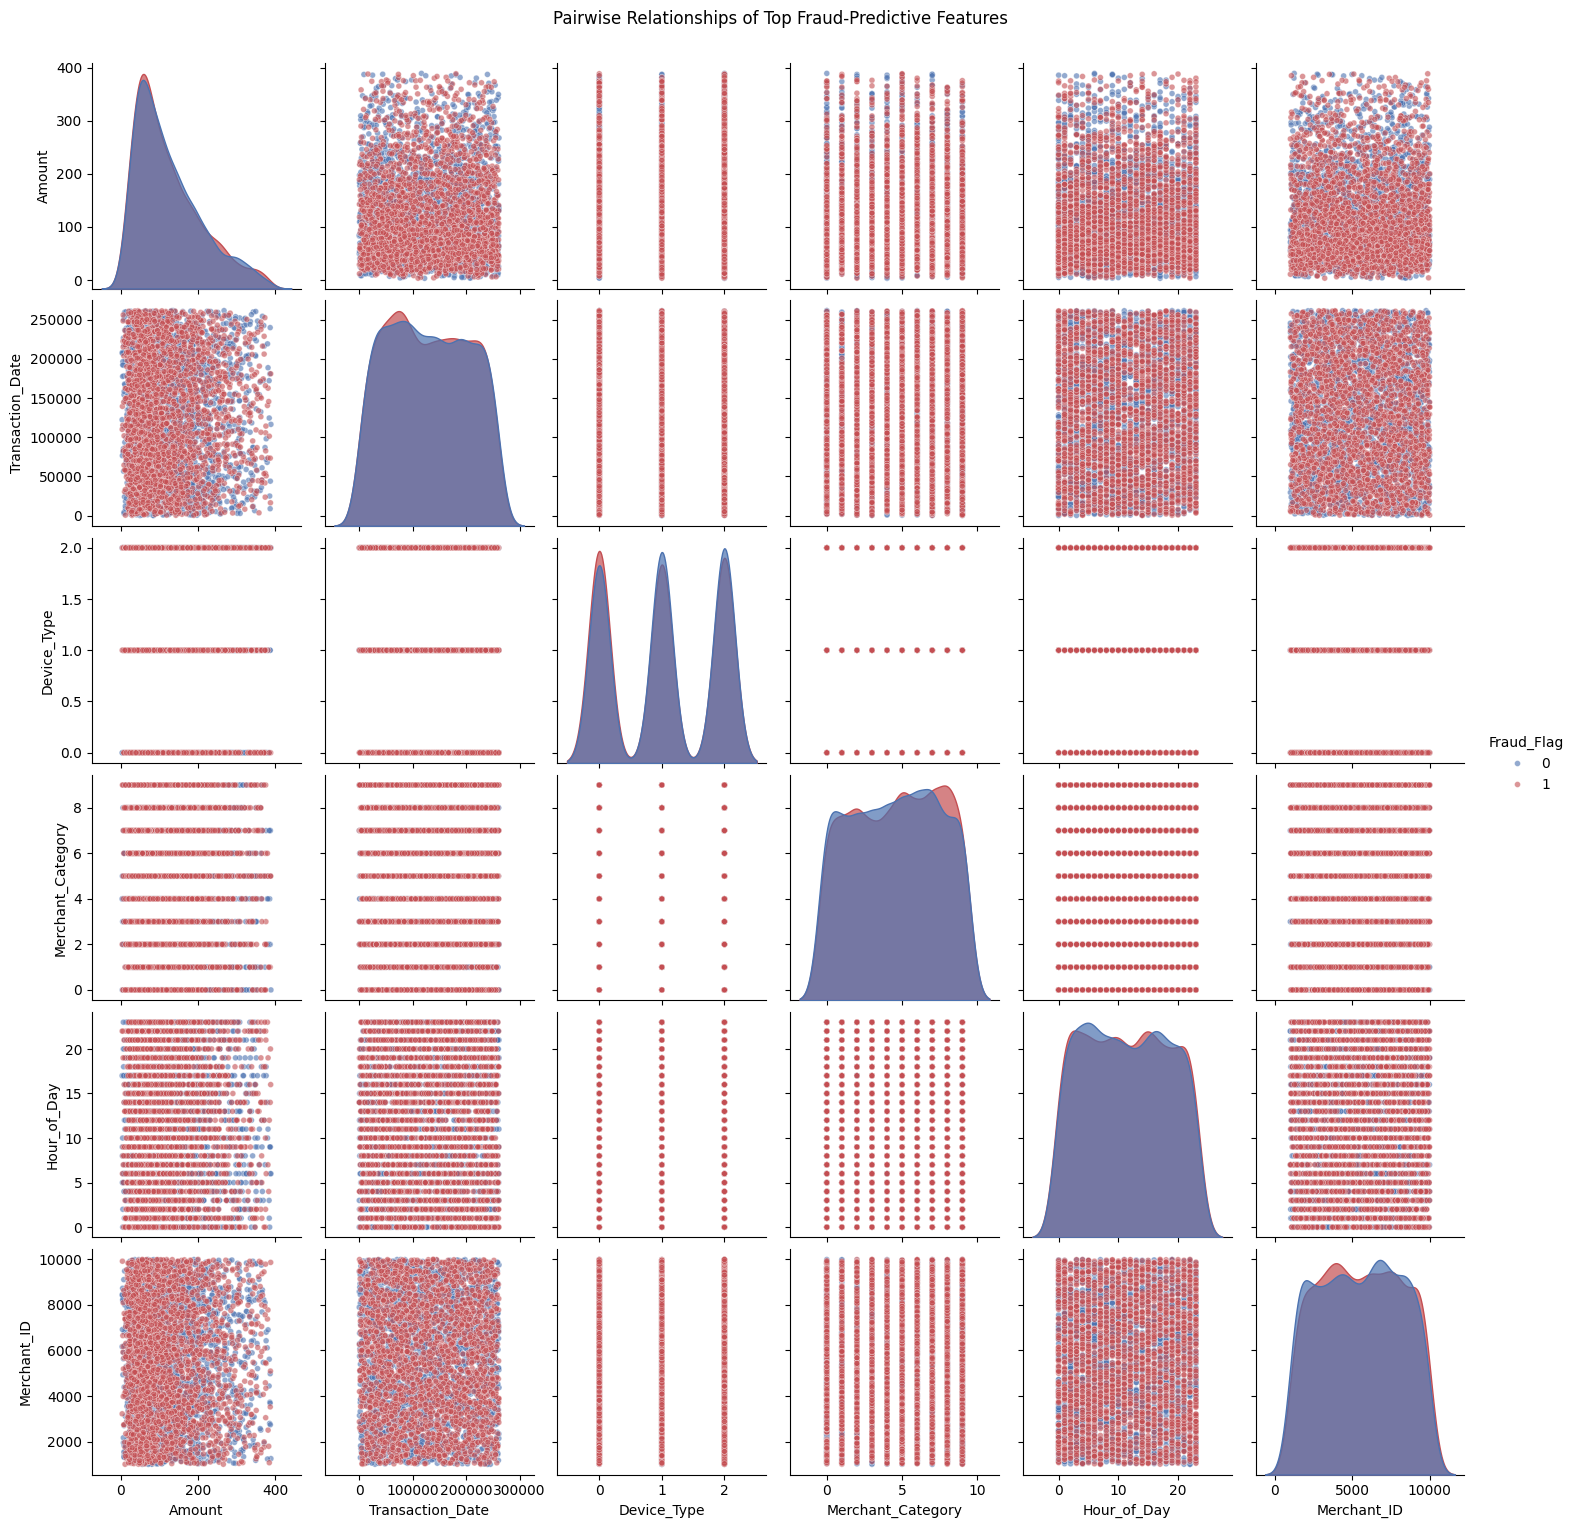

In [ ]:
# Pairplot (Stratified Sample)
def stratified_sample(df, target_col, n_per_class=2500):
    return df.groupby(target_col, group_keys=False).apply(
        lambda x: x.sample(min(len(x), n_per_class), random_state=42)
    )

df_sample = stratified_sample(df, target_col, n_per_class=2500)
print(f"Sampled {len(df_sample)} rows for pairplot.")

plt.figure(figsize=(12, 10))
sns.pairplot(data=df_sample, hue=target_col, vars=top_features,
             palette=['#4C72B0', '#C44E52'], diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 18}, diag_kws={'alpha': 0.7})
plt.suptitle('Pairwise Relationships of Top Fraud-Predictive Features', y=1.02)
plt.show()

Train-Test Split

In [ ]:
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train set: {X_train.shape[0]}, Test set: {X_test.shape[0]}")

Train set: 246685, Test set: 61672


In [ ]:
# Scale Numeric Features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
# Undersample Majority Class
rus = RandomUnderSampler(sampling_strategy=0.3, random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train_scaled, y_train)
print(f"After undersampling: {Counter(y_train_bal)}")

X_train_final = X_train_bal
y_train_final = y_train_bal
X_test_final = X_test_scaled
y_test_final = y_test

After undersampling: Counter({0: 12336, 1: 3701})


In [ ]:
# Define Classifiers

# Logistic Regression
log_reg = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)

# Naive Bayes
nb_classifier = GaussianNB()

# Random Forest
rforest = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=8,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# AdaBoost
adaboost = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.7,
    random_state=42
)

# XGBoost
scale_pos_weight = y_train_final.value_counts()[0] / y_train_final.value_counts()[1]
xgb_classifier = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    n_jobs=-1,
    random_state=42
)

# SVM
svm_classifier = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,   # needed for ROC
    random_state=42
)

# KNN
knn_classifier = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',  # closer points have more influence
    n_jobs=-1
)

# Stacking
stacking_classifier = StackingClassifier(
    estimators=[('lr', log_reg), ('nb', nb_classifier), ('rf', rforest)],
    final_estimator=LogisticRegression(
        max_iter=1000, solver='saga', class_weight='balanced', n_jobs=-1, random_state=42
    ),
    cv=5,
    n_jobs=-1
)

# Voting
voting_classifier = VotingClassifier(
    estimators=[('lr', log_reg), ('nb', nb_classifier), ('rf', rforest)],
    voting='soft',
    weights=[2,1,3],
    n_jobs=-1
)

In [ ]:
# Train and Evaluate

classifiers = [
    log_reg, nb_classifier, rforest, adaboost, xgb_classifier,
    svm_classifier, knn_classifier, voting_classifier, stacking_classifier
]

classifier_names = [
    "Logistic Regression", "Naive Bayes", "Random Forest", "AdaBoost", "XGBoost",
    "SVM", "KNN", "Voting Classifier", "Stacking Classifier"
]

results_list = []
y_pred_list = []

for clf, name in zip(classifiers, classifier_names):
    print(f"Training {name}.")
    clf.fit(X_train_final, y_train_final)

    y_pred = clf.predict(X_test_final)
    y_pred_list.append(y_pred)

    # Metrics
    accuracy = round(accuracy_score(y_test_final, y_pred), 4)
    report = classification_report(y_test_final, y_pred, output_dict=True, zero_division=0)
    f1 = round(report['weighted avg']['f1-score'],4)
    recall = round(report['weighted avg']['recall'],4)
    precision = round(report['weighted avg']['precision'],4)

    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test_final)[:,1]
    else:
        y_proba = clf.decision_function(X_test_final)
    auc_roc = round(roc_auc_score(y_test_final, y_proba),4)

    results_list.append([name, accuracy, f1, recall, precision, auc_roc])

Training Logistic Regression.
Training Naive Bayes.
Training Random Forest.
Training AdaBoost.
Training XGBoost.
Training SVM.
Training KNN.
Training Voting Classifier.
Training Stacking Classifier.


In [ ]:
# Display Results
results = pd.DataFrame(results_list, columns=["Classifier", "Accuracy", "Weighted F1 Score", "Recall", "Precision", "AUC-ROC"])
from tabulate import tabulate
print("Model Performance Table:")
print(tabulate(results, headers='keys', tablefmt='pretty'))

Model Performance Table:
+---+---------------------+----------+-------------------+--------+-----------+---------+
|   |     Classifier      | Accuracy | Weighted F1 Score | Recall | Precision | AUC-ROC |
+---+---------------------+----------+-------------------+--------+-----------+---------+
| 0 | Logistic Regression |  0.5026  |      0.6562       | 0.5026 |   0.97    | 0.4902  |
| 1 |     Naive Bayes     |  0.985   |      0.9776       | 0.985  |  0.9702   | 0.4943  |
| 2 |    Random Forest    |  0.8983  |      0.9326       | 0.8983 |  0.9705   | 0.5008  |
| 3 |      AdaBoost       |  0.985   |      0.9776       | 0.985  |  0.9702   | 0.4947  |
| 4 |       XGBoost       |  0.6313  |      0.7614       | 0.6313 |  0.9695   | 0.4862  |
| 5 |         SVM         |  0.5396  |      0.6883       | 0.5396 |  0.9702   | 0.4933  |
| 6 |         KNN         |  0.9009  |       0.934       | 0.9009 |  0.9706   | 0.5046  |
| 7 |  Voting Classifier  |  0.9848  |      0.9774       | 0.9848 |  0.9702

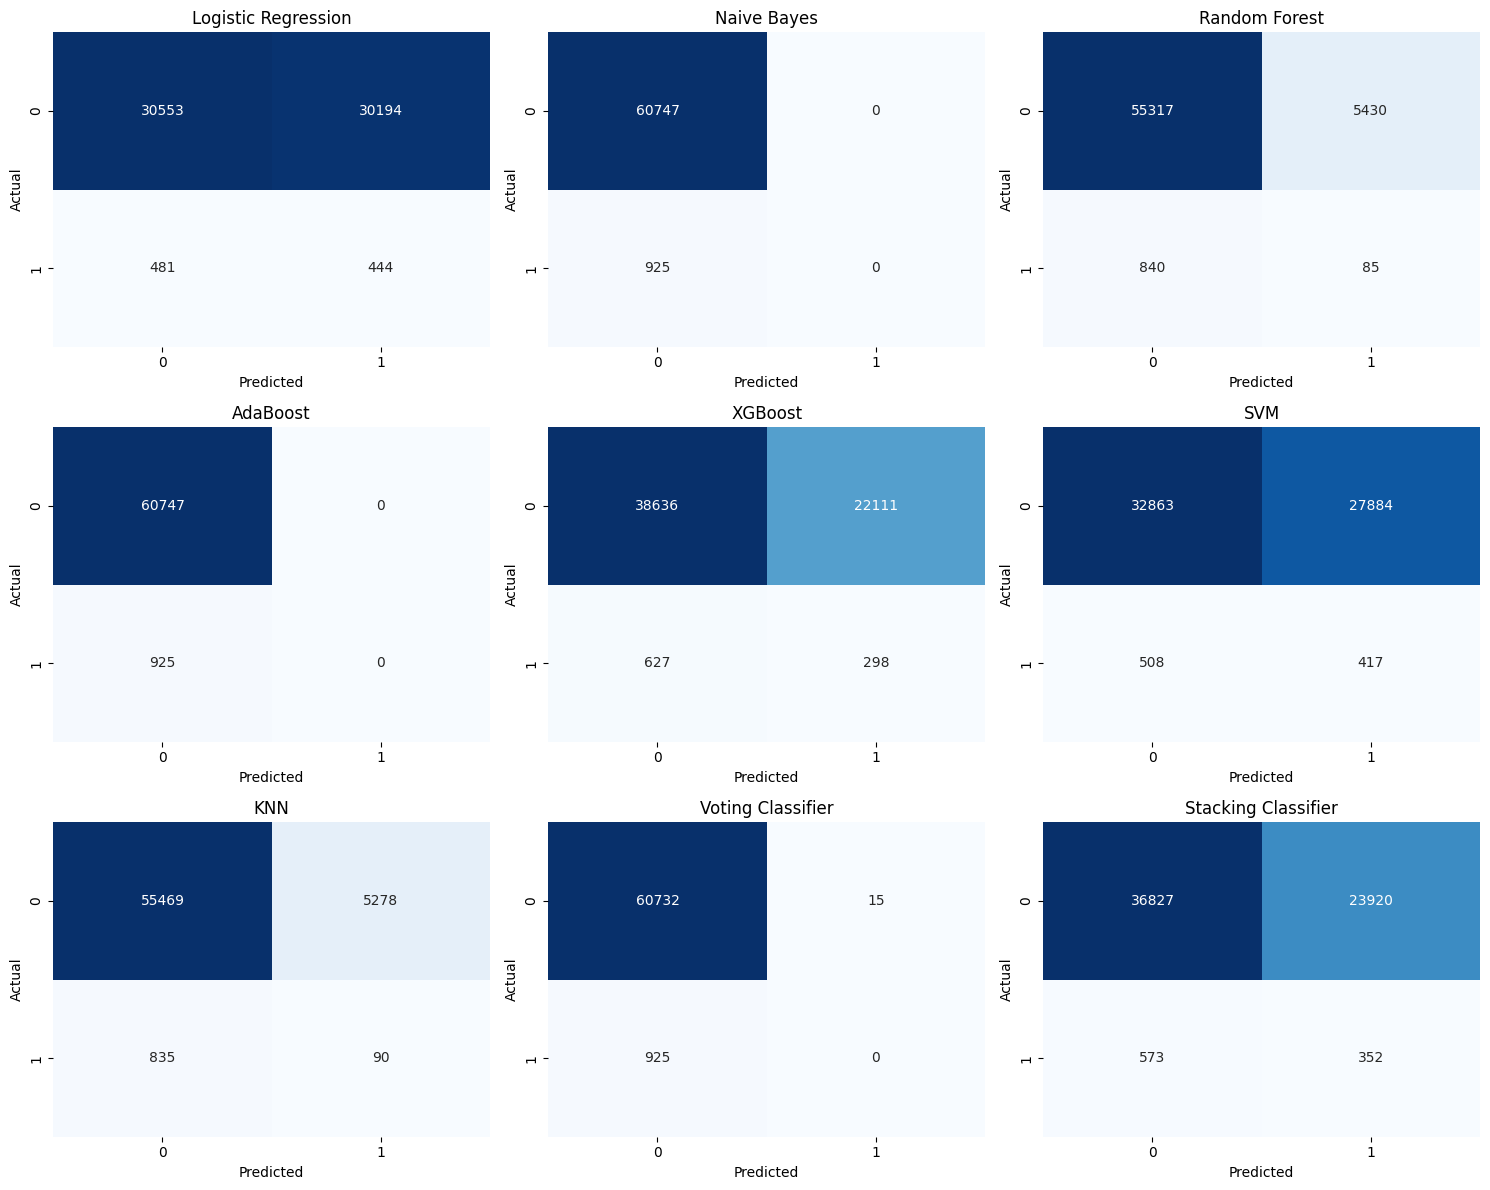

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(nrows=(len(classifiers)+2)//3, ncols=3, figsize=(5*3,4*((len(classifiers)+2)//3)))
axes = axes.flatten()

for i, (clf, name) in enumerate(zip(classifiers, classifier_names)):
    cm = confusion_matrix(y_test_final, y_pred_list[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

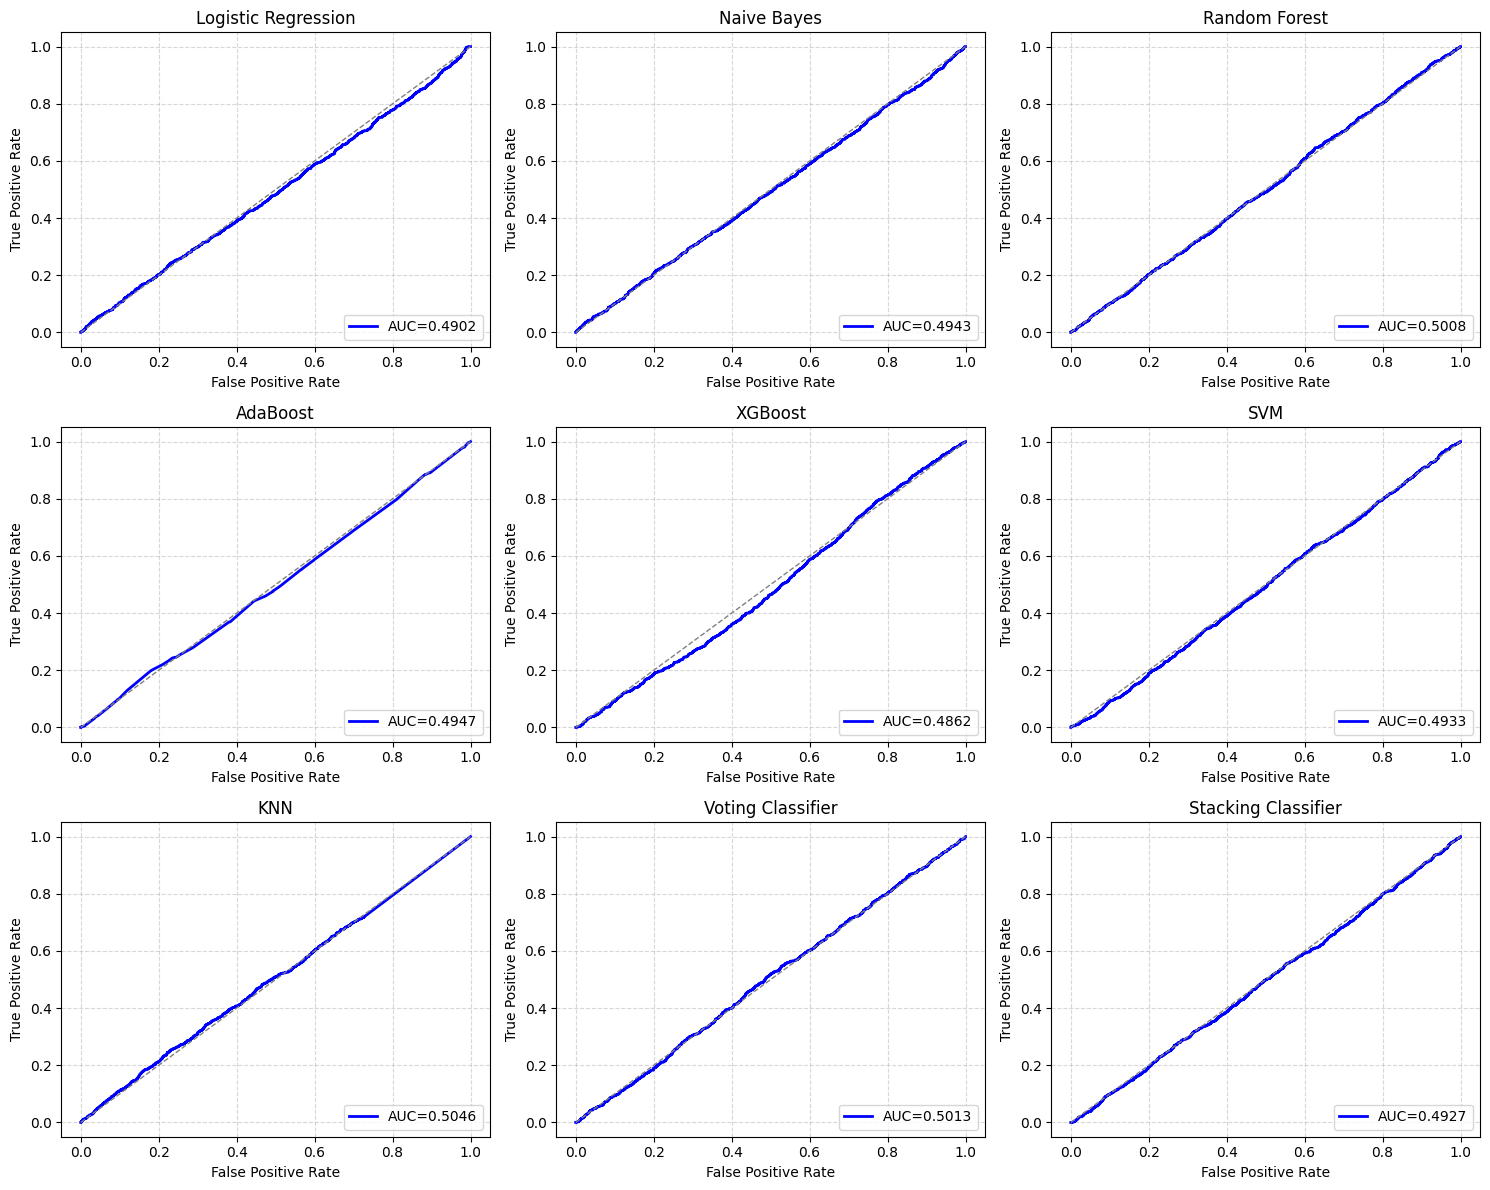

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve, auc
# Number of classifiers
n_models = len(classifiers)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, (clf, name) in enumerate(zip(classifiers, classifier_names)):
    # Get predicted probabilities
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test_final)[:, 1]
    else:
        y_proba = clf.decision_function(X_test_final)

    # Compute ROC
    fpr, tpr, _ = roc_curve(y_test_final, y_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC
    axes[i].plot(fpr, tpr, color='blue', lw=2, label=f"AUC={roc_auc:.4f}")
    axes[i].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    axes[i].set_title(name)
    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].legend(loc='lower right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')  # hide the empty subplots

plt.tight_layout()
plt.show()